In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/Global_Superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (51290, 24)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())


=== DATA TYPES ===
Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

=== MISSING VALUES ===
Postal Code    41296
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [6]:
# Convert Order Date and Ship Date from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Create Delivery Days column — how long did shipping take?
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Sample delivery days:")
print(df['Delivery Days'].describe())

Sample delivery days:
count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: Delivery Days, dtype: float64


In [7]:
# Postal Code has nulls and isn't needed for our analysis
df.drop(columns=['Postal Code'], inplace=True)

# Drop duplicate rows if any
df.drop_duplicates(inplace=True)

print("Cleaned shape:", df.shape)

Cleaned shape: (51290, 24)


In [8]:
# Profit Margin % = (Profit / Sales) * 100
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

# Create Year and Month columns for time analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

print("New columns added: Profit Margin %, Year, Month, Month Name")
df[['Sales', 'Profit', 'Profit Margin %', 'Delivery Days']].describe()

New columns added: Profit Margin %, Year, Month, Month Name


,Sales,Profit,Profit Margin %,Delivery Days
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,28.610982,4.743049,3.969370
std,487.565361,174.340972,46.566723,1.729437
min,0.444000,-6599.978000,-473.350000,0.000000
25%,30.758625,0.000000,0.000000,3.000000
50%,85.053000,9.240000,16.920000,4.000000
75%,251.053200,36.810000,33.310000,5.000000
max,22638.480000,8399.976000,50.000000,7.000000


In [9]:
df.to_csv('data/cleaned_superstore.csv', index=False)
print("✅ Clean file saved! Shape:", df.shape)

✅ Clean file saved! Shape: (51290, 28)


          Category  Total_Sales  Total_Profit  Profit_Margin
0        Furniture   4110874.19     285204.72           0.86
1  Office Supplies   3787070.23     518473.83           5.90
2       Technology   4744557.50     663778.73           4.97


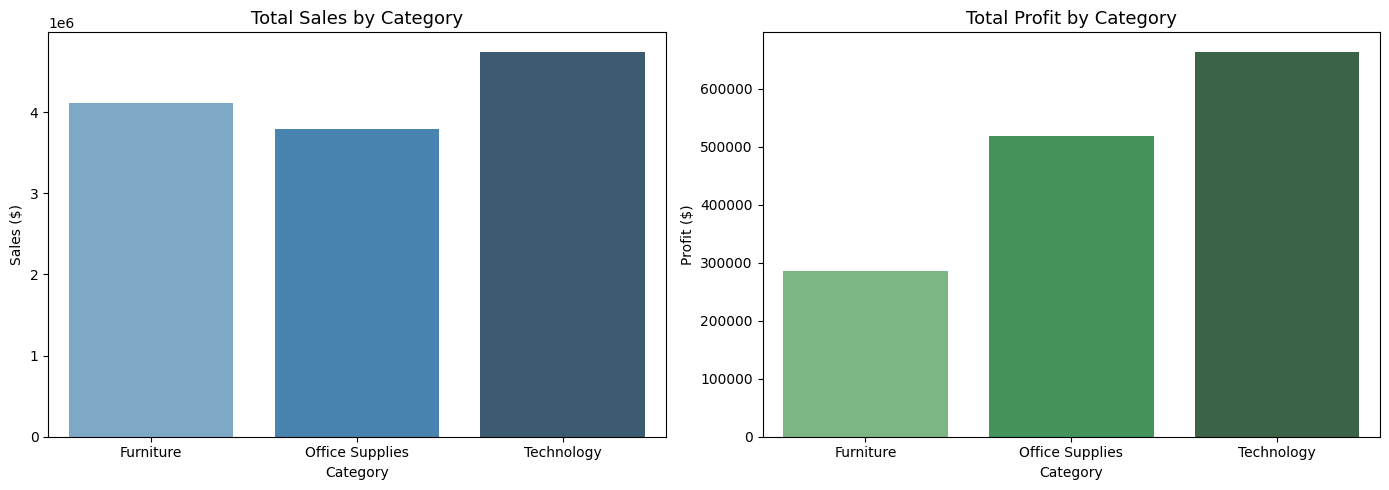

In [10]:
category_stats = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Profit_Margin=('Profit Margin %', 'mean')
).round(2).reset_index()

print(category_stats)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=category_stats, x='Category', y='Total_Sales', palette='Blues_d', ax=ax[0])
ax[0].set_title('Total Sales by Category', fontsize=13)
ax[0].set_ylabel('Sales ($)')

sns.barplot(data=category_stats, x='Category', y='Total_Profit', palette='Greens_d', ax=ax[1])
ax[1].set_title('Total Profit by Category', fontsize=13)
ax[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('category_sales_profit.png', dpi=150)
plt.show()

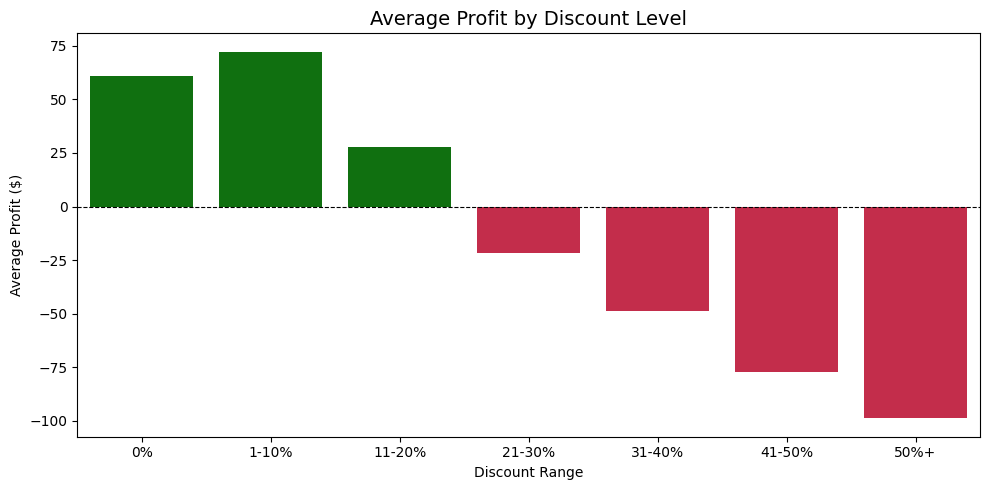

In [11]:
# Create discount buckets
df['Discount Bucket'] = pd.cut(df['Discount'],
    bins=[-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+'])

discount_profit = df.groupby('Discount Bucket')['Profit'].mean().reset_index()

plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'crimson' for x in discount_profit['Profit']]
sns.barplot(data=discount_profit, x='Discount Bucket', y='Profit', palette=colors)
plt.title('Average Profit by Discount Level', fontsize=14)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylabel('Average Profit ($)')
plt.xlabel('Discount Range')
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

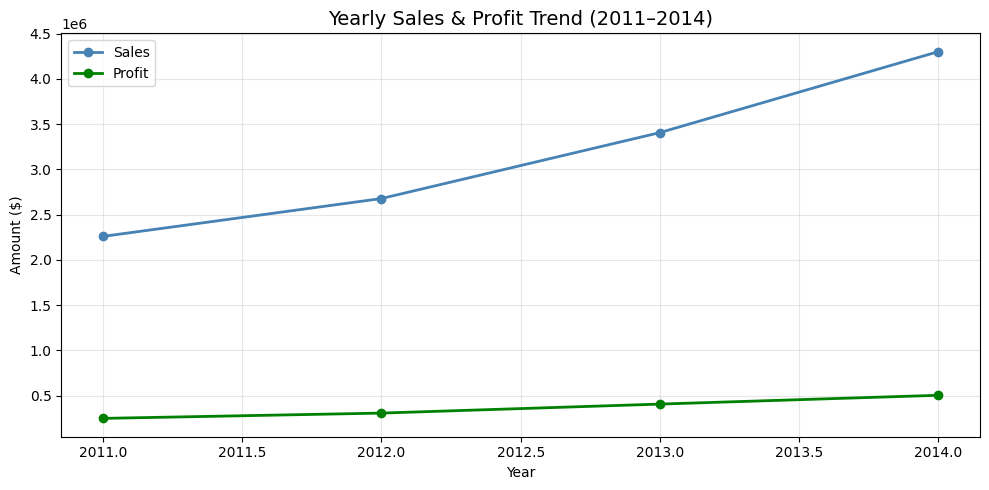

In [12]:
yearly = df.groupby('Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['Year'], yearly['Sales'], marker='o', label='Sales', color='steelblue', linewidth=2)
plt.plot(yearly['Year'], yearly['Profit'], marker='o', label='Profit', color='green', linewidth=2)
plt.title('Yearly Sales & Profit Trend (2011–2014)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()

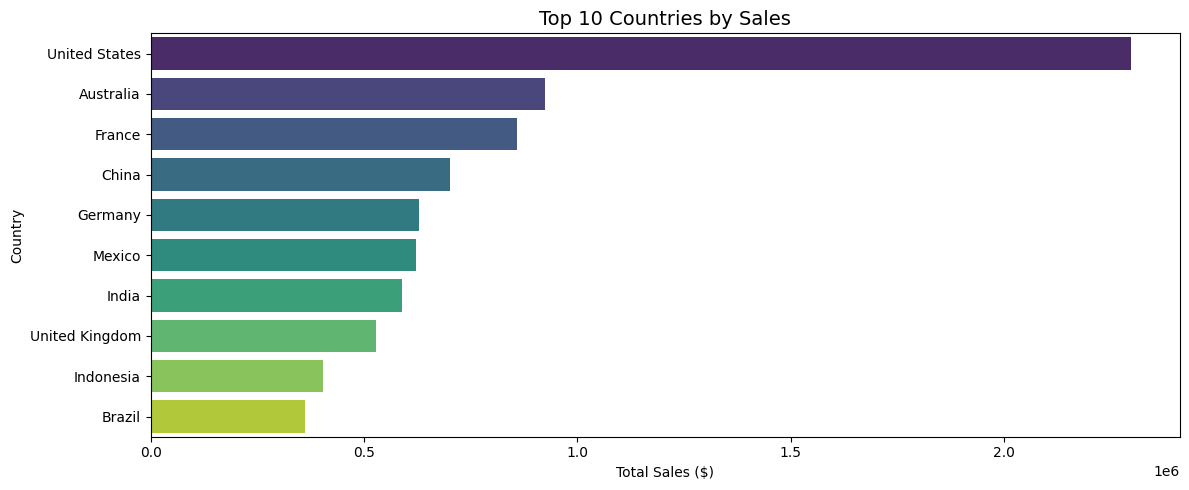

In [13]:
top_countries = df.groupby('Country')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x='Sales', y='Country', palette='viridis')
plt.title('Top 10 Countries by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

In [14]:
print("=" * 45)
print("         SUPERSTORE BUSINESS SUMMARY")
print("=" * 45)
print(f"Total Orders     : {df['Order ID'].nunique():,}")
print(f"Total Sales      : ${df['Sales'].sum():,.0f}")
print(f"Total Profit     : ${df['Profit'].sum():,.0f}")
print(f"Avg Profit Margin: {df['Profit Margin %'].mean():.1f}%")
print(f"Total Countries  : {df['Country'].nunique()}")
print(f"Avg Delivery Days: {df['Delivery Days'].mean():.1f} days")
print(f"\nMost Profitable Category : {category_stats.loc[category_stats['Total_Profit'].idxmax(), 'Category']}")
print(f"Least Profitable Category: {category_stats.loc[category_stats['Total_Profit'].idxmin(), 'Category']}")

         SUPERSTORE BUSINESS SUMMARY
Total Orders     : 25,035
Total Sales      : $12,642,502
Total Profit     : $1,467,457
Avg Profit Margin: 4.7%
Total Countries  : 147
Avg Delivery Days: 4.0 days

Most Profitable Category : Technology
Least Profitable Category: Furniture


In [16]:
# For each order, calculate:
# 1. Whether it contained any heavily discounted item (>30%)
# 2. The profit from non-discounted items in that same order

order_summary = df.groupby('Order ID').apply(lambda x: pd.Series({
    'has_heavy_discount': (x['Discount'] > 0.3).any(),
    'total_profit': x['Profit'].sum(),
    'non_discounted_profit': x[x['Discount'] <= 0.1]['Profit'].sum(),
    'avg_discount': x['Discount'].mean(),
    'num_items': len(x)
})).reset_index()

# Compare orders WITH vs WITHOUT heavy discounts
comparison = order_summary.groupby('has_heavy_discount').agg(
    avg_total_profit=('total_profit', 'mean'),
    avg_non_discounted_profit=('non_discounted_profit', 'mean'),
    avg_items_per_order=('num_items', 'mean'),
    total_orders=('Order ID', 'count')
).round(2)

print(comparison)

                    avg_total_profit  avg_non_discounted_profit  \
has_heavy_discount                                                
False                         113.16                     106.52   
True                         -122.51                      10.25   

                    avg_items_per_order  total_orders  
has_heavy_discount                                     
False                              1.97         19241  
True                               2.31          5794  


In [17]:
import sqlalchemy
import sqlite3

# Create a local SQLite database from your cleaned CSV
conn = sqlite3.connect('superstore.db')
df.to_sql('superstore', conn, if_exists='replace', index=False)
print("✅ Database created successfully!")

✅ Database created successfully!


In [19]:
query1 = """
SELECT
    COUNT(DISTINCT `Order ID`) AS total_orders,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Profit / Sales * 100), 2) AS avg_profit_margin_pct
FROM superstore
"""
print(pd.read_sql_query(query1, conn))

   total_orders  total_sales  total_profit  avg_profit_margin_pct
0         25035  12642501.91    1467457.29                   4.74


In [20]:
query2 = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit,
    ROUND(AVG(Profit / Sales * 100), 2) AS avg_margin_pct
FROM superstore
GROUP BY Category
ORDER BY total_profit DESC
"""
print(pd.read_sql_query(query2, conn))

          Category  total_sales  total_profit  avg_margin_pct
0       Technology   4744557.50     663778.73            4.97
1  Office Supplies   3787070.23     518473.83            5.90
2        Furniture   4110874.19     285204.72            0.86


In [21]:
query3 = """
SELECT
    `Order ID`,
    Category,
    `Sub-Category`,
    ROUND(Sales, 2) AS sales,
    ROUND(Profit, 2) AS profit,
    ROUND(Discount * 100, 0) AS discount_pct
FROM superstore
WHERE Profit < 0
ORDER BY Profit ASC
LIMIT 20
"""
print(pd.read_sql_query(query3, conn))

           Order ID         Category Sub-Category    sales   profit  \
0    CA-2013-108196       Technology     Machines  4499.98 -6599.98   
1      TU-2013-9400       Technology       Phones  3085.34 -4088.38   
2    US-2014-168116       Technology     Machines  7999.98 -3839.99   
3    CA-2011-169019  Office Supplies      Binders  2177.58 -3701.89   
4    CA-2014-134845       Technology     Machines  2549.99 -3399.98   
5   IT-2013-3695467  Office Supplies   Appliances  3399.66 -3059.82   
6     ID-2013-12295       Technology       Phones  3499.16 -3009.43   
7    US-2014-122714  Office Supplies      Binders  1889.99 -2929.48   
8      LH-2014-5390        Furniture       Tables  2171.16 -2750.28   
9    CA-2012-147830       Technology     Machines  1799.99 -2639.99   
10    ID-2014-26869        Furniture       Tables  1286.67 -2380.35   
11   CA-2014-131254  Office Supplies      Binders  1525.19 -2287.78   
12  IT-2013-5208514        Furniture       Chairs  2570.86 -2211.16   
13  IT

In [22]:
query4 = """
SELECT
    `Sub-Category`,
    ROUND(SUM(Profit), 2) AS total_profit
FROM superstore
GROUP BY `Sub-Category`
ORDER BY total_profit DESC
LIMIT 5
"""
print(pd.read_sql_query(query4, conn))

  Sub-Category  total_profit
0      Copiers     258567.55
1       Phones     216717.01
2    Bookcases     161924.42
3   Appliances     141680.59
4       Chairs     140396.27


In [23]:
query5 = """
SELECT
    strftime('%Y', `Order Date`) AS year,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(SUM(Profit), 2) AS total_profit
FROM superstore
GROUP BY year
ORDER BY year
"""
print(pd.read_sql_query(query5, conn))

   year  total_sales  total_profit
0  2011   2259450.90     248940.81
1  2012   2677438.69     307415.28
2  2013   3405746.45     406935.23
3  2014   4299865.87     504165.97
